In [468]:
import numpy as np
from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams['image.origin'] = 'lower'

from astropy.modeling import models
from astropy.stats import sigma_clipped_stats
from scipy.optimize import least_squares


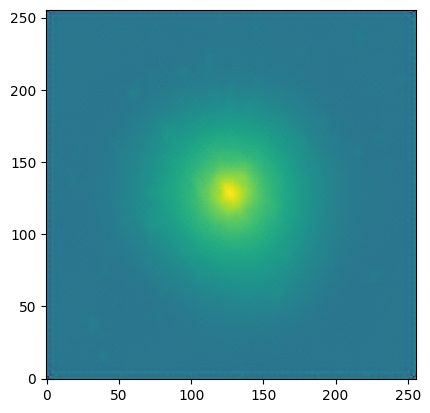

In [469]:
hdul = fits.open('unet_pred/final_predictions.fits')
image = hdul[2].data
plt.imshow(image)

In [ ]:
def extract_radial_profile(
    image,
    x0,
    y0,
    mask=None,
    r_min=1.0,
    r_max=None,
    dr=5.0,
    spacing="linear",
    n_bins=None,
    min_pixels=20,
):
    """
    Extract a circular median radial profile.

    Parameters
    ----------
    image : 2D ndarray
        Input image.
    x0, y0 : float
        Center in pixel.
    mask : 2D bool ndarray, optional
        True is masked.
    r_min, r_max : float
        Min and max radius in pixels.
    spacing : {'linear', 'log'}
        Radial bin spacing.
    n_bins : int, optional
        Number of radial bins. Or use dr.
    """
    image = np.asarray(image, dtype=float)

    if mask is None:
        mask = np.zeros_like(image, dtype=bool)
    else:
        mask = np.asarray(mask, dtype=bool)

    valid = np.isfinite(image) & (~mask)

    y, x = np.indices(image.shape)
    r_map = np.sqrt((x - x0)**2 + (y - y0)**2)

    if r_max is None:
        r_max = np.nanmax(r_map[valid])

    if spacing == "linear":
        if n_bins is None:
            edges = np.arange(r_min, r_max + dr, dr)
        else:
            edges = np.linspace(r_min, r_max, n_bins + 1)

    elif spacing == "log":
        if r_min <= 0:
            r_min = max(1.0, np.nanmin(r_map[valid & (r_map > 0)]))

        if n_bins is None:
            edges = 10 ** np.arange(np.log10(r_min), np.log10(r_max) + dr, dr)
            if edges[-1] > r_max: edges[-1] = r_max
        else:
            edges = np.logspace(np.log10(r_min), np.log10(r_max), n_bins + 1)

    r_list = []
    I_list = []

    for r1, r2 in zip(edges[:-1], edges[1:]):
        ann = valid & (r_map >= r1) & (r_map < r2)

        if np.count_nonzero(ann) < min_pixels:
            continue

        I_med = np.nanmedian(image[ann])

        if not np.isfinite(I_med):
            continue

        if spacing == "log":
            r_mid = np.sqrt(r1 * r2)
        else:
            r_mid = 0.5 * (r1 + r2)

        r_list.append(r_mid)
        I_list.append(I_med)

    return {"r": np.array(r_list),  "I_r": np.array(I_list)}

def fit_sersic1d_profile(
    r,
    I_r,
    fit_background=True,
    r_fit_min=None,
    r_fit_max=None,
    amplitude_init=None,
    r_eff_init=10.0,
    n_init=4.0,
    n_bounds=(0.4, 6.0),
    r_eff_bounds=None,
    amplitude_bounds=None,
    background_init=None,
    background_bounds=None
):
    """
    Fit a 1D Sérsic model in log intensity space.

    Parameters
    ----------
    r : 1D ndarray
        Radius in pixels.
    I_r : 1D ndarray
        Intensity profile.
    fit_background : bool
        Fit a constant background.
    r_fit_min, r_fit_max : float, optional
        Fitting range in pixels.
    r_eff_init : float
        Initial effective radius.
    n_init : float
        Initial Sérsic index.
    n_bounds : tuple
        Bounds for Sérsic index.
    """
    r = np.asarray(r, dtype=float)
    I_r = np.asarray(I_r, dtype=float)

    good = np.isfinite(r) & np.isfinite(I_r) & (r > 0) & (I_r > 0)

    if r_fit_min is not None:
        good &= r >= r_fit_min
    if r_fit_max is not None:
        good &= r <= r_fit_max

    r_fit = r[good]
    I_fit = I_r[good]

    if len(r_fit) < 5:
        raise ValueError("Not enough valid positive radial bins for fitting.")

    if r_eff_bounds is None:
        r_eff_bounds = (1.0, np.nanmax(r_fit))

    if amplitude_bounds is None:
        amplitude_bounds = (1e-30, 1e2 * np.nanmax(I_fit))

    if amplitude_init is None:
        order = np.argsort(r_fit)
        amplitude_init = np.interp(r_eff_init, r_fit[order], I_fit[order])

    if not np.isfinite(amplitude_init) or amplitude_init <= 0:
        amplitude_init = np.nanmedian(I_fit[I_fit > 0])

    _, background_init, _ = sigma_clipped_stats(I_fit, sigma=3.0, maxiters=5)

    if background_bounds is None:
        background_bounds = (-0.1, np.nanmedian(I_fit))

    p0 = [np.log(amplitude_init), np.log(r_eff_init),  n_init]

    lower = [np.log(amplitude_bounds[0]), np.log(r_eff_bounds[0]), n_bounds[0]]
    upper = [np.log(amplitude_bounds[1]), np.log(r_eff_bounds[1]), n_bounds[1]]

    if fit_background:
        p0.append(background_init)
        lower.append(background_bounds[0])
        upper.append(background_bounds[1])

    p0 = np.asarray(p0, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    p0 = np.clip(p0, lower + 1e-12, upper - 1e-12)

    log_I_fit = np.log10(I_fit)

    def residuals(p):
        amp = np.exp(p[0])
        r_eff = np.exp(p[1])
        n = p[2]
        bkg = p[3] if fit_background else 0.0

        sersic = models.Sersic1D(amplitude=amp, r_eff=r_eff, n=n)

        I_model = sersic(r_fit) + bkg
        bad_pixels = (~np.isfinite(I_model)) | (I_model <= 0)

        res = np.full_like(I_fit, 1e10, dtype=float)
        res[~bad_pixels] = np.log10(I_model[~bad_pixels]) - log_I_fit[~bad_pixels]

        return res

    fit = least_squares(residuals, p0, bounds=(lower, upper), max_nfev=1000)

    if not fit.success: print("Sérsic fit failed.")

    amp_best = float(np.exp(fit.x[0]))
    r_eff_best = float(np.exp(fit.x[1]))
    n_best = float(fit.x[2])
    bkg_best = float(fit.x[3]) if fit_background else 0.0

    sersic_best = models.Sersic1D(amplitude=amp_best, r_eff=r_eff_best, n=n_best)

    if fit_background:
        model_best = sersic_best + models.Const1D(amplitude=bkg_best)
    else:
        model_best = sersic_best

    return {
        "model": model_best,
        "r_eff": r_eff_best,
        "n": n_best,
        "amp": amp_best,
        "bkg": bkg_best,
    }


def plot_sersic1d_fit(
    r,
    I_r,
    fit_result,
    r_plot_min=None,
    r_plot_max=None,
    figsize=(5.5, 5),
):
    """
    Compact plot of the Sérsic fit.

    Parameters
    ----------
    r : 1D ndarray
        Radius in pixels.
    I_r : 1D ndarray
        Intensity profile.
    fit_result : dict
        Output from fit.
    """

    good = np.isfinite(r) & np.isfinite(I_r) & (r > 0) & (I_r > 0)

    if r_plot_min is not None:
        good &= r >= r_plot_min
    if r_plot_max is not None:
        good &= r <= r_plot_max

    r_use = r[good]
    I_use = I_r[good]

    model = fit_result["model"]

    r_grid = np.logspace( np.log10(np.nanmin(r_use)), np.log10(np.nanmax(r_use)), 200)

    I_model_grid = model(r_grid)
    I_model_data = model(r_use)

    fig, (ax, ax_res) = plt.subplots(2,1,figsize=figsize,sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.03})

    ax.plot(r_use, I_use, "o", ms=4,alpha=0.8, label="Input")
    ax.plot(r_grid, I_model_grid, "-", lw=2, alpha=0.9, label="Sersic")

    if fit_result.get("bkg", None) is not None:
        ax.axhline(fit_result["bkg"], ls="--", color='gray', lw=1, alpha=0.7, label="Background")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"$I(r)$")
    ax.legend(fontsize=10, frameon=False)

    text = (rf"$R_e={fit_result['r_eff']:.1f}$, $n={fit_result['n']:.3g}$, $bkg={fit_result['bkg']:.2f}$")

    ax.text(0.04, 0.05, text, transform=ax.transAxes, va="bottom", ha="left", fontsize=10)

    del_I = np.log10(I_use) - np.log10(I_model_data)
    ylabel = r"$\Delta\log I$"

    ax_res.axhline(0, lw=1, color='k', alpha=0.7)
    ax_res.plot(r_use, del_I, "o", ms=5, alpha=0.8)

    ax_res.set_xscale("log")
    ax_res.set_xlabel("Radius [pix]")
    ax_res.set_ylabel(ylabel)

    ax.tick_params(labelsize=10)
    ax_res.tick_params(labelsize=10)
    plt.show()

In [471]:
input = 10**(image+30)

Text(0, 0.5, 'Intensity I(r)')

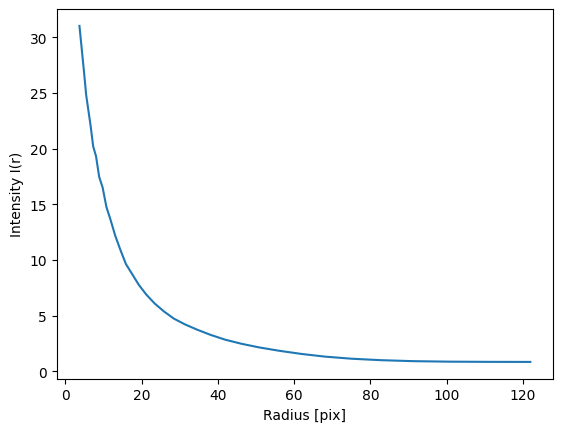

In [475]:
profile = extract_radial_profile(
    input,
    x0=127.5,
    y0=127.5,
    spacing="log",
    mask=None,
    n_bins=50,
    r_max=128)

plt.plot(profile['r'], profile['I_r'])
plt.xlabel('Radius [pix]')
plt.ylabel('Intensity I(r)')

In [478]:
fit_result = fit_sersic1d_profile(
    profile["r"],
    profile["I_r"],
    fit_background=False,
    r_eff_init=50,
    r_fit_min=10,
    r_fit_max=100,
    n_init=4.0,
    n_bounds=(0.4, 6.0)
)

print("R_e =", fit_result["r_eff"])
print("n   =", fit_result["n"])
print("bkg =", fit_result["bkg"])

R_e = 91.13921251821137
n   = 2.9898880508933203
bkg = 0.0


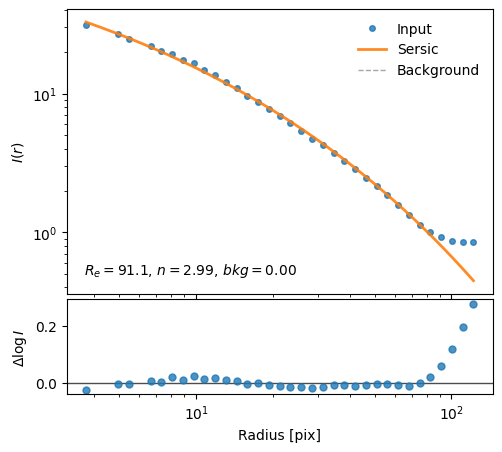

In [479]:
plot_sersic1d_fit(profile["r"], profile["I_r"], fit_result)